In [20]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 15


In [42]:
with open("all_group_errors.pkl", "rb") as f:
    all_group_errors = pickle.load(f)
all_group_errors

[{487: {487: 0.16782116339086217,
   436: 0.11791072670401127,
   469: 0.18679765267759985,
   459: 0.32720184570453203,
   463: 0.35011449709166714,
   484: 0.18773045270374758,
   448: 0.18223958619471106,
   446: 0.2933347606878789,
   500: 0.26446931436657906,
   489: 0.2931141196326776,
   473: 0.48400135819728557},
  436: {487: 0.1749406793214222,
   436: 0.10903306912692372,
   469: 0.185657070252833,
   459: 0.38336865897061395,
   463: 0.3817436013508726,
   484: 0.16200446130346452,
   448: 0.1950878298708371,
   446: 0.3655045917715694,
   500: 0.3755974844098091,
   489: 0.36130141284824774,
   473: 0.45820781634404106},
  469: {487: 0.1765659794290649,
   436: 0.12100568185906765,
   469: 0.18122233073260133,
   459: 0.30959684413964633,
   463: 0.3369317873392576,
   484: 0.18869301273640413,
   448: 0.19022143339472158,
   446: 0.27194026735473853,
   500: 0.24528449214994907,
   489: 0.27064682297747245,
   473: 0.4801386065207995},
  459: {487: 0.3582348889928866,
   4

In [43]:
data_groups = []
for idx, each_car_errors in enumerate(all_group_errors):
    confusion_matrix = np.zeros((len(each_car_errors), len(each_car_errors)))
    for i, car_id in enumerate(each_car_errors.keys()):
        for j, car_data_id in enumerate(each_car_errors.keys()):
            confusion_matrix[i, j] = each_car_errors[car_id][car_data_id]
    for i in range(len(each_car_errors)):
        for j in range(len(each_car_errors)):
            if confusion_matrix[i, j] < confusion_matrix[i, i]:
                confusion_matrix[i, j] = 0.0
    for i in range(len(each_car_errors)):
        confusion_matrix[i, :] = confusion_matrix[i, :] - confusion_matrix[i, i]
    confusion_matrix[confusion_matrix < 0] = 0.0

    # For each row_i and col_i, find sum of that row and column as the error score of that car
    car_error_scores = {}
    for i, car_id in enumerate(each_car_errors.keys()):
        row_sum = np.sum(confusion_matrix[i, :]) / len(each_car_errors)
        col_sum = np.sum(confusion_matrix[:, i]) / len(each_car_errors)

        car_error_scores[car_id] = row_sum + 2 * col_sum
    data_groups.append({"name": f"Group {idx+1}", "data": car_error_scores})

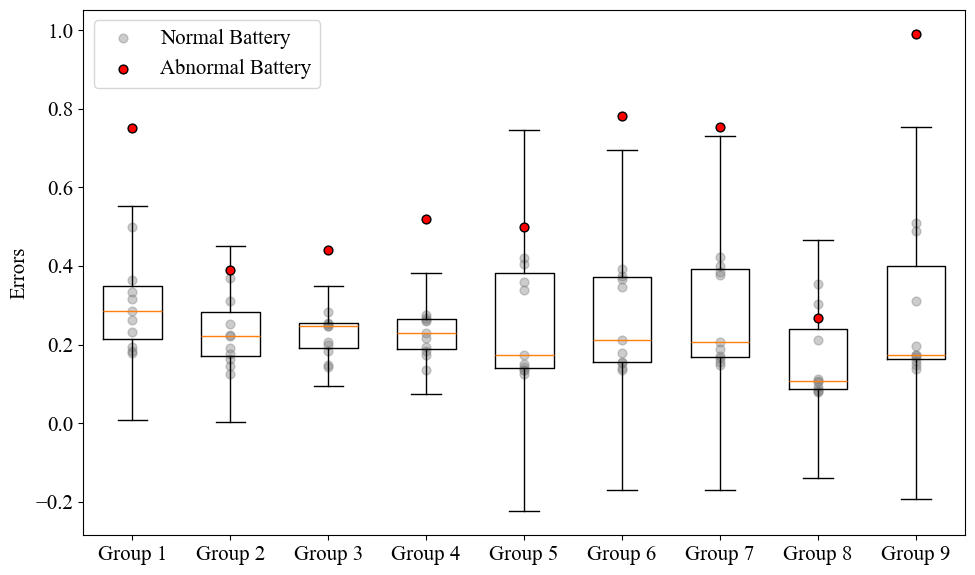

In [94]:
fig, ax = plt.subplots(figsize=(10, 6))

# Formatting for the internal labels
text_style = dict(va='center', ha='center', fontweight='bold', fontsize=9,
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Loop through each group to plot
for i, group in enumerate(data_groups):
    pos = i + 1  # X-position for the boxplot
    vals = list(group["data"].values())
    
    # Identify normal vs abnormal (last point)
    normal_vals = vals[:-1]
    abnormal_val = vals[-1]
    
    # Calculate Stats
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    iqr = q3 - q1
    whislo, whishi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    
    # 1. Plot the Boxplot at position 'pos'
    stats = [{'label': group["name"], 'q1': q1, 'med': med, 'q3': q3, 
              'whislo': whislo, 'whishi': whishi, 'fliers': []}]
    ax.bxp(stats, positions=[pos], showfliers=False, widths=0.6)
    
    # # 2. Add Internal Labels (Q1, Med, Q3)
    # ax.text(pos, q3, f'Q3:{q3:.2f}', color='darkred', **text_style)
    # ax.text(pos, med, f'M:{med:.2f}', color='green', **text_style)
    # ax.text(pos, q1, f'Q1:{q1:.2f}', color='blue', **text_style)
    
    # # 3. Add Whisker Labels
    # ax.text(pos, whishi + 0.02, f'Max:{whishi:.2f}', color='black', ha='center', fontsize=8)
    # ax.text(pos, whislo - 0.02, f'Min:{whislo:.2f}', color='black', ha='center', va='top', fontsize=8)
    
    # 4. Plot Scatter Points
    # x_jitter = np.random.normal(pos, 0.04, size=len(normal_vals))
    x_jitter = [pos] * len(normal_vals)
    ax.scatter(x_jitter, normal_vals, color='gray', alpha=0.4, s=40, label='Normal Battery' if i==0 else "")
    
    # Plot Abnormal Point
    ax.scatter([pos], [abnormal_val if i==0 else abnormal_val], color='red', 
               s=40, edgecolors='black', zorder=5, label='Abnormal Battery' if i==0 else "")

# Final Formatting
ax.set_ylabel('Errors')
# ax.set_title('Multi-Group Comparison with Custom Labels')
ax.set_xticks(range(1, len(data_groups) + 1))
ax.set_xticklabels([g["name"] for g in data_groups])
ax.legend()

plt.tight_layout()
plt.savefig("iqr_error_plot.png", dpi=300)
plt.show()

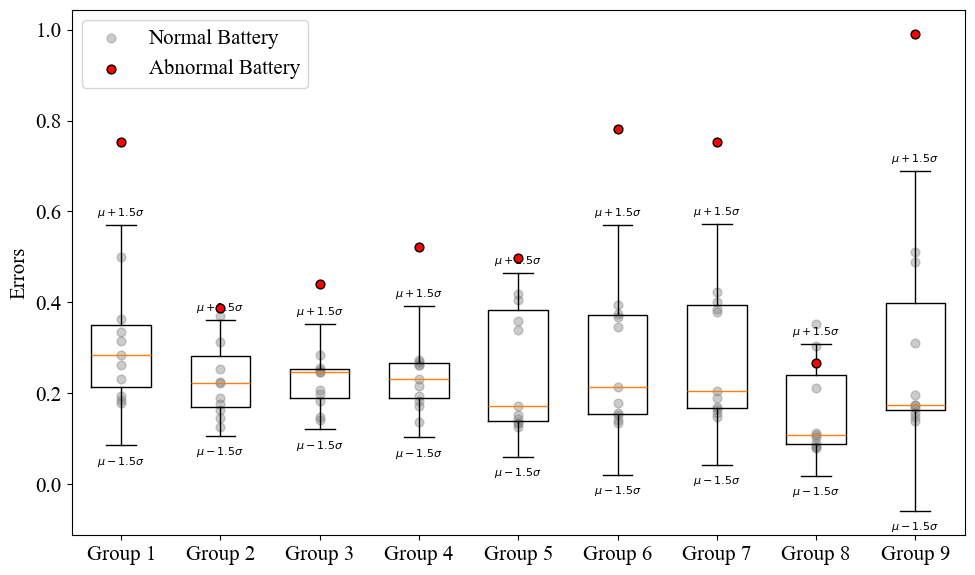

In [93]:
fig, ax = plt.subplots(figsize=(10, 6))

# Formatting for the internal labels
text_style = dict(va='center', ha='center', fontweight='bold', fontsize=9,
                  bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

# Loop through each group to plot
for i, group in enumerate(data_groups):
    pos = i + 1  # X-position for the boxplot
    vals = list(group["data"].values())
    mean_val = float(np.mean(vals))
    std_val = float(np.std(vals))
    
    # Identify normal vs abnormal (last point)
    normal_vals = vals[:-1]
    abnormal_val = vals[-1]
    
    # Calculate Stats
    q1, med, q3 = np.percentile(vals, [25, 50, 75])
    whislo, whishi = mean_val - 1.5 * std_val, mean_val + 1.5 * std_val
    
    # 1. Plot the Boxplot at position 'pos'
    stats = [{'label': group["name"], 'q1': q1, 'med': med, 'q3': q3, 
              'whislo': whislo, 'whishi': whishi, 'fliers': []}]
    ax.bxp(stats, positions=[pos], showfliers=False, widths=0.6)
    
    # # 2. Add Internal Labels (Q1, Med, Q3)
    # ax.text(pos, q3, f'Q3:{q3:.2f}', color='darkred', **text_style)
    # ax.text(pos, med, f'M:{med:.2f}', color='green', **text_style)
    # ax.text(pos, q1, f'Q1:{q1:.2f}', color='blue', **text_style)
    
    # 3. Add Whisker Labels
    ax.text(pos, whishi + 0.02, f'$\mu+1.5\sigma$', color='black', ha='center', fontsize=8)
    ax.text(pos, whislo - 0.02, f'$\mu-1.5\sigma$', color='black', ha='center', va='top', fontsize=8)
    
    # 4. Plot Scatter Points
    # x_jitter = np.random.normal(pos, 0.04, size=len(normal_vals))
    x_jitter = [pos] * len(normal_vals)
    ax.scatter(x_jitter, normal_vals, color='gray', alpha=0.4, s=40, label='Normal Battery' if i==0 else "")
    
    # Plot Abnormal Point
    ax.scatter([pos], [abnormal_val if i==0 else abnormal_val], color='red', 
               s=40, edgecolors='black', zorder=5, label='Abnormal Battery' if i==0 else "")

# Final Formatting
ax.set_ylabel('Errors')
# ax.set_title('Multi-Group Comparison with Custom Labels')
ax.set_xticks(range(1, len(data_groups) + 1))
ax.set_xticklabels([g["name"] for g in data_groups])
ax.legend()

plt.tight_layout()
plt.savefig("mean_std_error_plot.png", dpi=300)
plt.show()

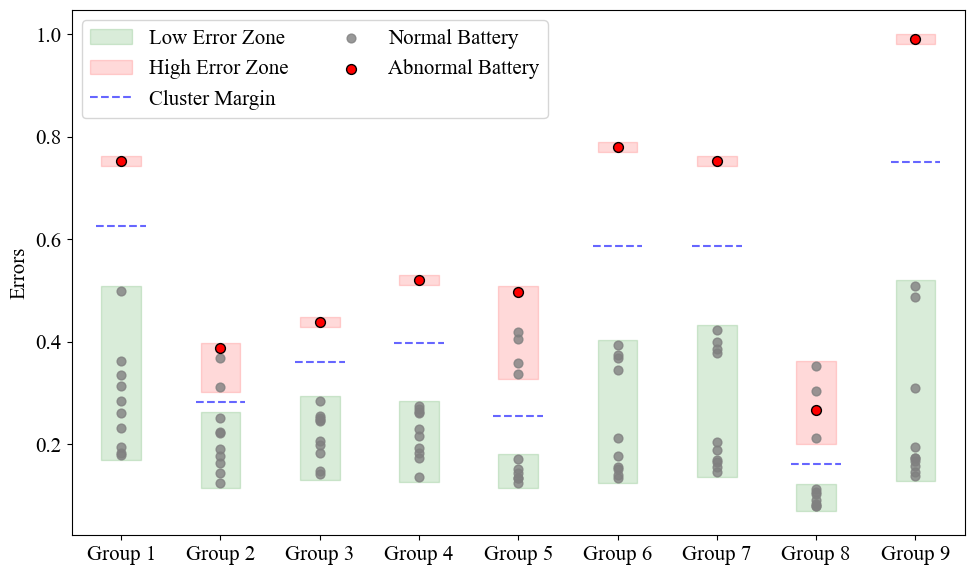

In [92]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming data_groups is your list of dicts
# data_groups = [...]

fig, ax = plt.subplots(figsize=(10, 6))

# Define the vertical padding for the boxes
padding = 0.01 

for i, group in enumerate(data_groups):
    # 1. Sort by value to find the gap
    sorted_items = sorted(group["data"].items(), key=lambda x: x[1])
    values = np.array([item[1] for item in sorted_items])

    # 2. Find the gap and split the groups
    gaps = np.diff(values)
    max_gap_index = np.argmax(gaps)
    avg_other_gaps = np.mean(gaps)

    pos = i + 1
    
    if gaps[max_gap_index] > (avg_other_gaps * 2):
        # Define the sub-sets
        group_lower_vals = values[:max_gap_index + 1]
        group_upper_vals = values[max_gap_index + 1:]
        
        # Horizontal width for the box and the line
        x_min, x_max = pos - 0.2, pos + 0.2
        
        # 3. GREEN RECTANGLE (Lower Group) with padding
        y_min_low = min(group_lower_vals) - padding
        y_max_low = max(group_lower_vals) + padding
        ax.fill_between([x_min, x_max], y_min_low, y_max_low, 
                        color='green', alpha=0.15, edgecolor='green', 
                        linewidth=1, label='Low Error Zone' if i==0 else "")
        
        # 4. RED RECTANGLE (Upper Group) with padding
        y_min_up = min(group_upper_vals) - padding
        y_max_up = max(group_upper_vals) + padding
        ax.fill_between([x_min, x_max], y_min_up, y_max_up, 
                        color='red', alpha=0.15, edgecolor='red', 
                        linewidth=1, label='High Error Zone' if i==0 else "")
        
        # 5. ADD THE SPLIT LINE (Centered in the gap)
        max_gap = gaps[max_gap_index]
        lower_cluster_max = max(group_lower_vals)
        gap_mid = lower_cluster_max + (max_gap / 2)
        
        ax.hlines(y=gap_mid, xmin=x_min - 0.05, xmax=x_max + 0.05, 
                  color='blue', linestyle='--', linewidth=1.5, alpha=0.6,
                  label='Cluster Margin' if i==0 else "")

    # 6. Plot Points
    vals = list(group["data"].values())
    normal_vals = vals[:-1]
    abnormal_val = vals[-1]
    
    # Normal points
    ax.scatter([pos] * len(normal_vals), normal_vals, color='gray', alpha=0.8, s=40, 
               zorder=10, label = "Normal Battery")
    
    # Abnormal point
    ax.scatter([pos], [abnormal_val], color='red', s=50, edgecolors='black', 
               zorder=11, label='Abnormal Battery' if i==0 else "")

# Formatting
ax.set_ylabel('Errors')
ax.set_xticks(range(1, len(data_groups) + 1))
ax.set_xticklabels([g["name"] for g in data_groups])
ax.set_xlim(0.5, len(data_groups) + 0.5)

# Clean legend
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), ncol=2)

plt.tight_layout()
plt.savefig("cluster_error_zones.png", dpi=300)
plt.show()

In [16]:
with open("data3.txt", "r") as f:
    data = f.readlines()
with open("data4.txt", "w") as f:
    for line in data:
        tokens = line.split()
        line = ",".join(tokens)
        f.write(line + "\n")

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data2.txt")
df

,method,acc,f1,pre,rec,acc.1,f1.1,pre.1,rec.1,acc.2,f1.2,pre.2,rec.2
0,DyAD,0.9313,0.6667,0.6556,0.6889,0.9232,0.5926,0.5556,0.6667,0.9273,0.6556,0.6408,0.6889
1,DyAD,0.0085,0.0262,0.0249,0.0497,0.0153,0.0741,0.0879,0.0786,0.0132,0.0361,0.0361,0.0497
2,1DCNN,0.9576,0.8074,0.7889,0.8445,0.9576,0.6518,0.6333,0.6889,0.9272,0.7637,0.7255,0.8889
3,1DCNN,0.0132,0.0549,0.0609,0.0609,0.0132,0.0562,0.0633,0.0497,0.0314,0.0511,0.0647,0.0000
4,Transformer,0.9556,0.7778,0.7667,0.8000,0.9455,0.4889,0.4778,0.5111,0.9030,0.7504,0.7000,0.9333
5,Transformer,0.0055,0.0454,0.0465,0.0497,0.0055,0.0884,0.0843,0.0994,0.0153,0.0529,0.0495,0.0994
6,LSTM,0.9536,0.8148,0.7889,0.8667,0.9596,0.7037,0.6778,0.7556,0.9495,0.8178,0.7815,0.9111
7,LSTM,0.0055,0.0454,0.0609,0.0497,0.0071,0.0693,0.0609,0.0930,0.0189,0.0522,0.0623,0.0497
8,Propose,0.9576,0.7852,0.7666,0.8222,0.9596,0.6000,0.5889,0.6222,0.8909,0.7556,0.7033,0.9556
9,Propose,0.0111,0.0609,0.0609,0.0609,0.0071,0.0884,0.0843,0.0994,0.0431,0.0555,0.0672,0.0609


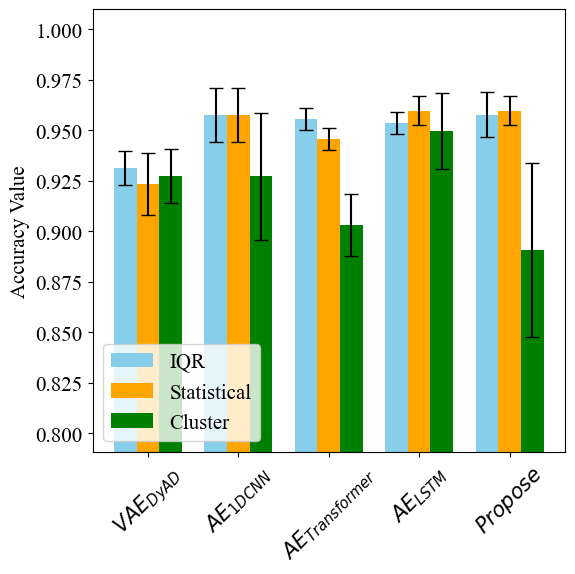

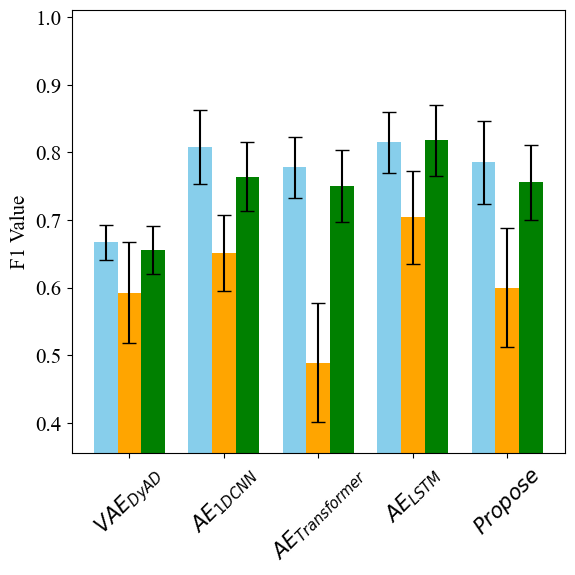

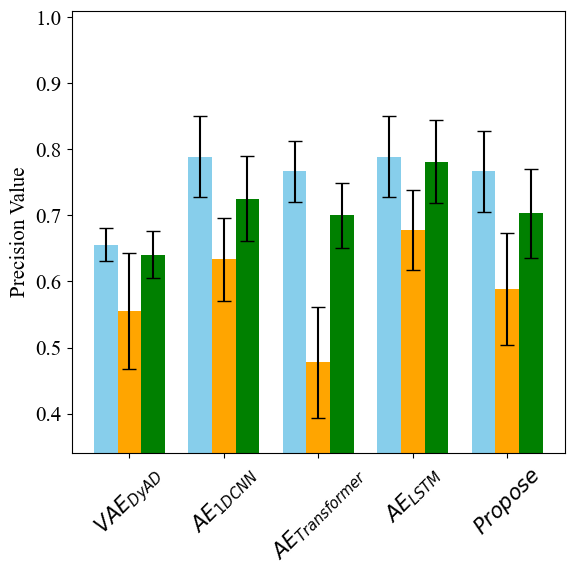

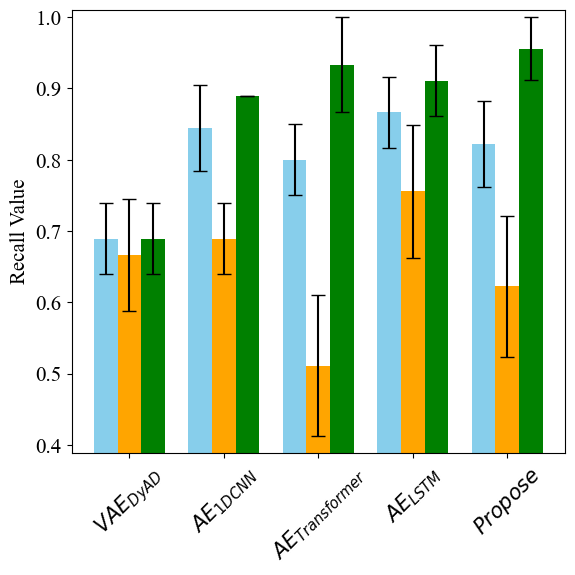

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 15

# Load the data
df = pd.read_csv("data2.txt")

# Extract method names (every other row starting from 0)
methods = df['method'][::2].reset_index(drop=True)
methods = ["${}$".format(m) for m in methods]

# Define metric groups
metrics_groups = {
    'Accuracy': ['acc', 'acc.1', 'acc.2'],
    'F1': ['f1', 'f1.1', 'f1.2'],
    'Precision': ['pre', 'pre.1', 'pre.2'],
    'Recall': ['rec', 'rec.1', 'rec.2']
}

categories = ['IQR', 'Statistical', 'Cluster']
colors = ['skyblue', 'orange', 'green']

# Prepare mean and std data
mean_df = df.iloc[::2].reset_index(drop=True)
std_df = df.iloc[1::2].reset_index(drop=True)

# Plot each metric separately
for metric_name, metric_cols in metrics_groups.items():
    x = np.arange(len(methods))
    width = 0.25

    fig, ax = plt.subplots(figsize=(6, 6))

    for i, (col, cat, color) in enumerate(zip(metric_cols, categories, colors)):
        means = mean_df[col]
        stds = std_df[col]
        means = np.minimum(means, 1.0) 
        stds = np.minimum(stds, 1.0 - means)
        ax.bar(x + i*width - width, means, width, yerr=stds, 
               label=cat, color=color, capsize=5)

    # Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45)
    ax.set_ylabel(f'{metric_name} Value')
    ax.set_ylim(min(means)-0.3, 1.01)
    # ax.set_title(f'{metric_name} by Method and Category')
    if metric_name == 'Accuracy':
        ax.set_ylim(min(means)-0.1, 1.01)
        ax.legend(loc='lower left')
    plt.tight_layout()
    plt.savefig(f"bar_plot_{metric_name.lower()}.png", dpi=300)
    plt.show()


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("data4.txt")
df

,alphaVSbeta,acc,f1,pre,rec,acc.1,f1.1,pre.1,rec.1,acc.2,f1.2,pre.2,rec.2
0,1vs1,0.9434,0.7333,0.6889,0.8222,0.9455,0.5704,0.5333,0.6445,0.8950,0.6968,0.6388,0.8667
1,1vs1,0.0055,0.0310,0.0304,0.0609,0.0055,0.0422,0.0497,0.0497,0.0354,0.0398,0.0266,0.1217
2,1vs2,0.9576,0.7852,0.7666,0.8222,0.9596,0.6000,0.5889,0.6222,0.8909,0.7556,0.7033,0.9556
3,1vs2,0.0111,0.0609,0.0609,0.0609,0.0071,0.0884,0.0843,0.0994,0.0431,0.0555,0.0672,0.0609
4,1vs3,0.9616,0.8000,0.7778,0.8445,0.9495,0.5111,0.5000,0.5334,0.9010,0.7497,0.7006,0.9333
5,1vs3,0.0111,0.0562,0.0556,0.0609,0.0101,0.1093,0.1040,0.1217,0.0330,0.0525,0.0652,0.0609
6,1vs4,0.9596,0.8000,0.7778,0.8445,0.9475,0.4444,0.4333,0.4667,0.8950,0.7645,0.7117,0.9556
7,1vs4,0.0101,0.0562,0.0556,0.0609,0.0085,0.1636,0.1542,0.1826,0.0382,0.0616,0.0729,0.0609
8,1vs5,0.9576,0.7926,0.7666,0.8445,0.9434,0.4222,0.4111,0.4444,0.8889,0.7512,0.6950,0.9556
9,1vs5,0.0085,0.0562,0.0609,0.0609,0.0115,0.1584,0.1501,0.1757,0.0335,0.0506,0.0631,0.0609


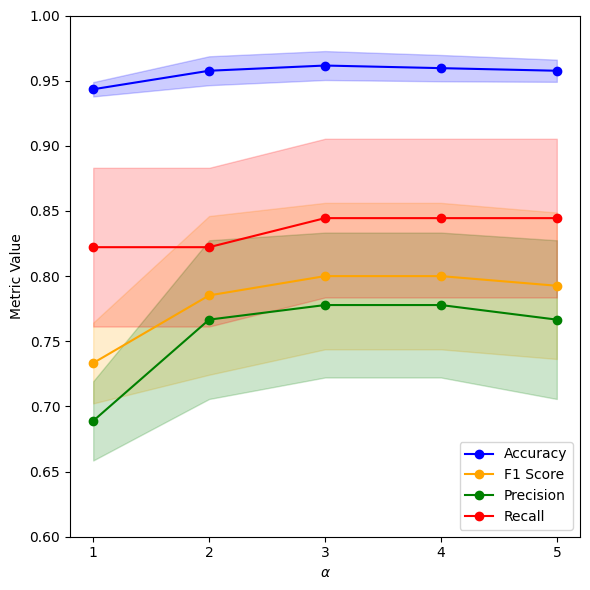

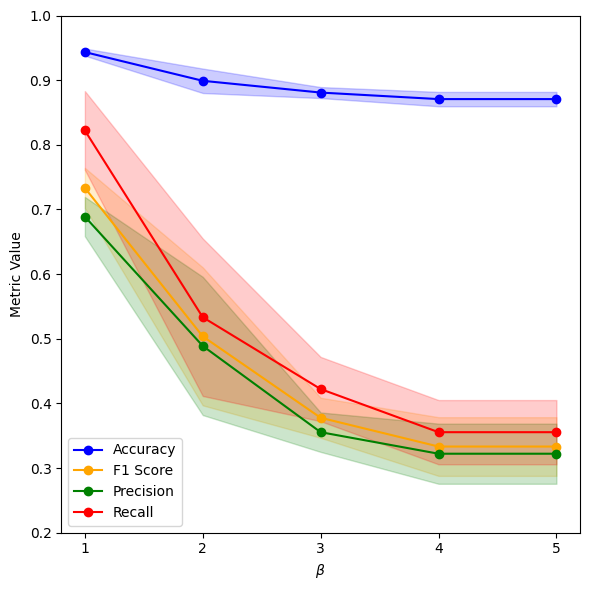

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("data4.txt")

# Separate mean and std rows
mean_df = df.iloc[::2].reset_index(drop=True)
std_df = df.iloc[1::2].reset_index(drop=True)

# Define metrics
metrics = ['acc', 'f1', 'pre', 'rec']
labels = ['Accuracy', 'F1 Score', 'Precision', 'Recall']
colors = ['blue', 'orange', 'green', 'red']

# --- Alpha = 1 fixed ---
alpha1_mean = mean_df[mean_df['alphaVSbeta'].str.startswith('1vs')]
alpha1_std = std_df[std_df['alphaVSbeta'].str.startswith('1vs')]
x_alpha = [int(s.split('vs')[1]) for s in alpha1_mean['alphaVSbeta']]  # beta values

plt.figure(figsize=(6,6))
for metric, label, color in zip(metrics, labels, colors):
    plt.plot(x_alpha, alpha1_mean[metric], marker='o', color=color, label=label)
    plt.fill_between(x_alpha,
                     alpha1_mean[metric] - alpha1_std[metric],
                     alpha1_mean[metric] + alpha1_std[metric],
                     color=color, alpha=0.2)
# plt.title("Alpha = 1 fixed (1vsX)")
# plt.xlabel("Beta")
plt.xlabel("$\\alpha$") # Changed to Alpha for consistency with the paper
plt.ylabel("Metric Value")
plt.ylim(0.6, 1.0)
plt.xticks(x_alpha)
plt.legend()
plt.tight_layout()
plt.savefig("abla_alpha1_fixed.png", dpi=300)
plt.show()

# --- Beta = 1 fixed ---
beta1_mean = mean_df[mean_df['alphaVSbeta'].str.endswith('vs1')]
beta1_std = std_df[std_df['alphaVSbeta'].str.endswith('vs1')]
x_beta = [int(s.split('vs')[0]) for s in beta1_mean['alphaVSbeta']]  # alpha values

plt.figure(figsize=(6,6))
for metric, label, color in zip(metrics, labels, colors):
    plt.plot(x_beta, beta1_mean[metric], marker='o', color=color, label=label)
    plt.fill_between(x_beta,
                     beta1_mean[metric] - beta1_std[metric],
                     beta1_mean[metric] + beta1_std[metric],
                     color=color, alpha=0.2)
# plt.title("Beta = 1 fixed (Xvs1)")
# plt.xlabel("Alpha")
plt.xlabel("$\\beta$") # Changed to Beta for consistency with the paper
plt.ylabel("Metric Value")
plt.ylim(0.2, 1.0)
plt.xticks(x_beta)
plt.legend()
plt.tight_layout()
plt.savefig("abla_beta1_fixed.png", dpi=300)
plt.show()
